In [222]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create results folder
os.makedirs('results', exist_ok=True)

In [223]:
# Load dataset
df = pd.read_csv('customer_churn_nn.csv')

print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (2000, 17)


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


# Task 1: Dataset Understanding

In [224]:
# Basic information
print('Number of Rows:', df.shape[0])
print('Number of Columns:', df.shape[1])

print('\nData Types:')
print(df.dtypes)

# Missing values
print('\nMissing Values:')
print(df.isnull().sum())

# Statistical summary
print('\nStatistical Summary:')
print(df.describe(include='all'))

# Plot target distribution
print('\nTarget Distribution:')
print(df['churn'].value_counts())
print('\nTarget Distribution (%):')
print(df['churn'].value_counts(normalize=True) * 100)

Number of Rows: 2000
Number of Columns: 17

Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr          

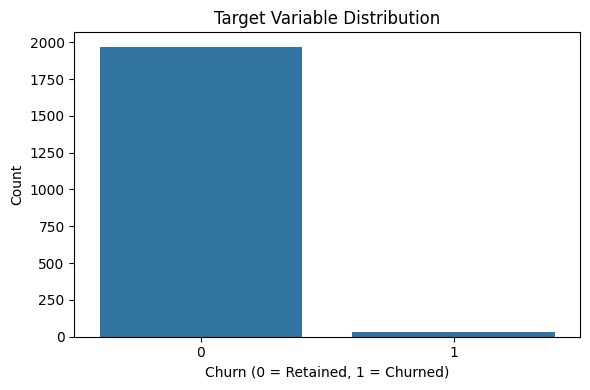

In [225]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn')
plt.title('Target Variable Distribution')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('results/target_distribution.png')
plt.show()

Interpretation

The dataset is highly imbalanced, with only 31 churn cases out of 2,000 observations. This means accuracy alone is not a reliable metric. Precision, recall, and F1-score are more informative.

# Task 2: Data Preprocessing

In [226]:
# Separate features and target(drop identifier)
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print('Categorical Columns:', categorical_cols)
print('Numerical Columns:', numerical_cols)

Categorical Columns: ['region', 'plan_type', 'contract_type', 'payment_method']
Numerical Columns: ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']


In [227]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Training Set:', X_train.shape)
print('Testing Set:', X_test.shape)

Training Set: (1600, 15)
Testing Set: (400, 15)


Why Stratified Split?

Since churn cases are rare, stratify=y ensures both training and testing sets preserve the same class proportions.

In [228]:
# Numerical preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Processed Training Shape:', X_train_processed.shape)
print('Processed Testing Shape:', X_test_processed.shape)

Processed Training Shape: (1600, 28)
Processed Testing Shape: (400, 28)


# Task 3: Neural Network Model Building

In [229]:
def build_model(input_dim,
                hidden_layers=[32, 16],
                activation='relu',
                learning_rate=0.001,
                dropout_rate=0.2):

    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for neurons in hidden_layers:
        model.add(Dense(neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [230]:
input_dim = X_train_processed.shape[1]

model = build_model(
    input_dim=input_dim,
    hidden_layers=[32, 16],
    activation='relu',
    learning_rate=0.001,
    dropout_rate=0.2
)

model.summary()

Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_138 (Dense)               │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_87 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_139 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_88 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_140 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Training and Evaluation

In [231]:
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
print('Class Weights:', class_weights)

Class Weights: {np.int64(0): np.float64(0.5079365079365079), np.int64(1): np.float64(32.0)}


In [232]:
# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3930 - loss: 0.7650 - val_accuracy: 0.5406 - val_loss: 0.6861
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5898 - loss: 0.7184 - val_accuracy: 0.6656 - val_loss: 0.6106
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6500 - loss: 0.6894 - val_accuracy: 0.7031 - val_loss: 0.6034
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6492 - loss: 0.5991 - val_accuracy: 0.7531 - val_loss: 0.5701
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7016 - loss: 0.6501 - val_accuracy: 0.7625 - val_loss: 0.5450
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7398 - loss: 0.6249 - val_accuracy: 0.7688 - val_loss: 0.5287
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7148 - loss: 0.5589 - val_accuracy: 0.7500 - val_loss: 0.5256
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7219 - loss: 0.5385 - val_accuracy: 0.7563 - v

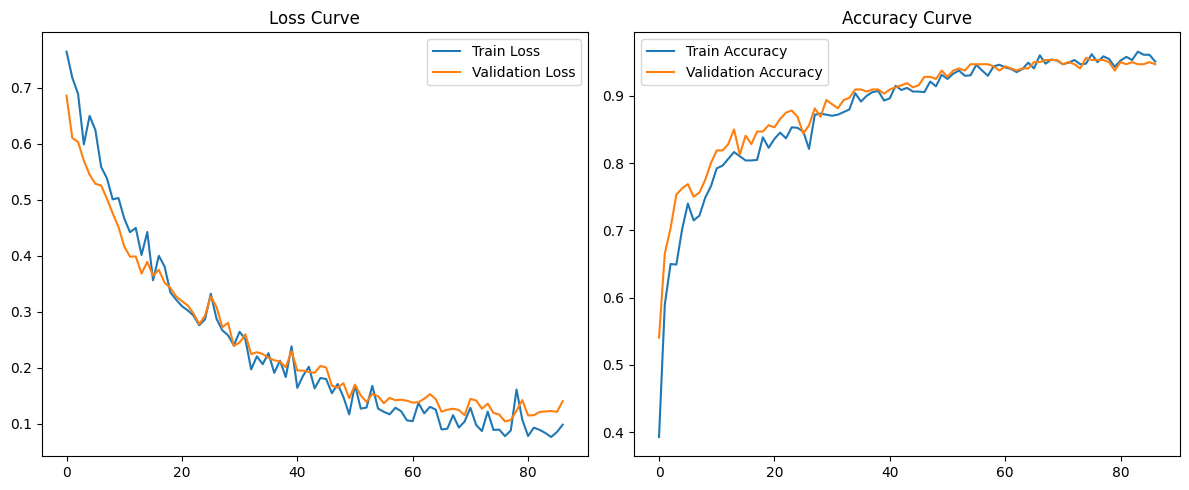

In [233]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss Curve')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png')
plt.show()

In [234]:
# Training metrics
train_loss, train_accuracy = model.evaluate(X_train_processed, y_train, verbose=0)

# Testing metrics
test_loss, test_accuracy = model.evaluate(X_test_processed, y_test, verbose=0)

print(f'Training Loss: {train_loss:.4f}')
print(f'Training Accuracy: {train_accuracy:.4f}')
print(f'Testing Loss: {test_loss:.4f}')
print(f'Testing Accuracy: {test_accuracy:.4f}')

Training Loss: 0.0696
Training Accuracy: 0.9725
Testing Loss: 0.1164
Testing Accuracy: 0.9650


In [235]:
y_pred_prob = model.predict(X_test_processed)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       394
           1       0.10      0.17      0.12         6

    accuracy                           0.96       400
   macro avg       0.54      0.57      0.55       400
weighted avg       0.97      0.96      0.97       400



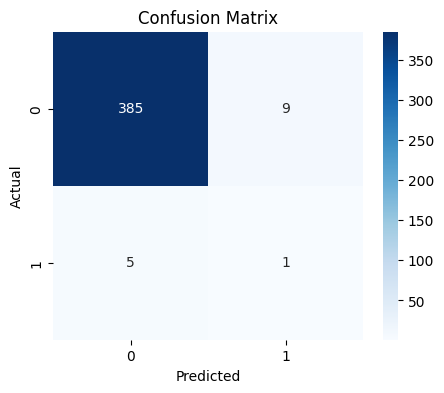

In [236]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Task 5: Hyperparameter Experimentation

In [237]:
def run_experiment(config):
    model = build_model(
        input_dim=input_dim,
        hidden_layers=config['hidden_layers'],
        activation=config['activation'],
        learning_rate=config['learning_rate'],
        dropout_rate=0.2
    )

    history = model.fit(
        X_train_processed,
        y_train,
        validation_split=0.2,
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        class_weight=class_weights,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=0
    )

    y_prob = model.predict(X_test_processed, verbose=0)
    y_pred = (y_prob > 0.5).astype(int)

    return {
        'Experiment': config['name'],
        'Hidden Layers': str(config['hidden_layers']),
        'Activation': config['activation'],
        'Learning Rate': config['learning_rate'],
        'Batch Size': config['batch_size'],
        'Epochs': config['epochs'],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0)
    }

In [238]:
experiments = [
    {
        'name': 'Exp 1',
        'hidden_layers': [16],
        'activation': 'relu',
        'learning_rate': 0.001,
        'batch_size': 32,
        'epochs': 50
    },
    {
        'name': 'Exp 2',
        'hidden_layers': [32, 16],
        'activation': 'relu',
        'learning_rate': 0.001,
        'batch_size': 32,
        'epochs': 100
    },
    {
        'name': 'Exp 3',
        'hidden_layers': [64, 32],
        'activation': 'relu',
        'learning_rate': 0.0005,
        'batch_size': 64,
        'epochs': 100
    },
    {
        'name': 'Exp 4',
        'hidden_layers': [32, 16],
        'activation': 'tanh',
        'learning_rate': 0.001,
        'batch_size': 32,
        'epochs': 100
    }
]

In [239]:
results = []

for config in experiments:
    print(f"Running {config['name']}...")
    result = run_experiment(config)
    results.append(result)

comparison_df = pd.DataFrame(results)
comparison_df

Running Exp 1...
Running Exp 2...
Running Exp 3...
Running Exp 4...


,Experiment,Hidden Layers,Activation,Learning Rate,Batch Size,Epochs,Accuracy,Precision,Recall,F1-Score
0,Exp 1,[16],relu,0.0010,32,50,0.9050,0.078947,0.500000,0.136364
1,Exp 2,"[32, 16]",relu,0.0010,32,100,0.9125,0.108108,0.666667,0.186047
2,Exp 3,"[64, 32]",relu,0.0005,64,100,0.9050,0.000000,0.000000,0.000000
3,Exp 4,"[32, 16]",tanh,0.0010,32,100,0.7900,0.056818,0.833333,0.106383


In [240]:
comparison_df.to_csv('results/model_comparison_table.csv', index=False)
print('Saved to results/model_comparison_table.csv')

Saved to results/model_comparison_table.csv


# **Task 6: Final Reflection**

## 1. What role do weights and biases play in the model?

Weights determine how strongly each input feature influences a neuron’s output. During training, the model adjusts these weights to minimize prediction error.

Biases are additional learnable parameters that allow neurons to shift the activation function. They help the model fit the data more flexibly.


       







## 2. Why is an activation function required?

Activation functions introduce non-linearity into the network. Without them, no matter how many layers are added, the model would behave like a simple linear model.

Functions such as ReLU and Sigmoid introduce non-linearity allowing the neural network to learn complex patterns and relationships.

## 3. What happens when the learning rate is too high or too low?
Too high: The optimizer may overshoot the optimal solution and fail to converge, causing unstable training or failure to converge.  
Too low: Training becomes very slow and may get stuck in poor local minima before reaching a good solution.

A suitable learning rate balances speed and stability.

## 4. Did the model show signs of underfitting or overfitting?

The training and validation curves were used to assess model behavior.

If both training and validation performance are poor, the model is underfitting.
If training performance is excellent but validation performance is much worse, the model is overfitting.

In this project, early stopping and dropout were used to reduce overfitting.